In [1]:
import torch
import matplotlib.pyplot as plt
from graphs import plot_loss_flattening
from sklearn.metrics import RocCurveDisplay, ConfusionMatrixDisplay

In [2]:
device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")
print(f"Using device: {device}")

Using device: mps


In [3]:
from models.densenet import run

path = "./normalized_images"

num_epochs = 10
lr = 1e-4
threshold = 0.6

model, train_losses, eval_losses, eval_preds, eval_labels, test_preds, test_labels = run(path, device, num_epochs=num_epochs, lr=lr, test=True, threshold=threshold)

Downloading: "https://download.pytorch.org/models/densenet121-a639ec97.pth" to /Users/madsfjeldberg/.cache/torch/hub/checkpoints/densenet121-a639ec97.pth


100%|██████████| 30.8M/30.8M [00:00<00:00, 50.1MB/s]


-- DenseNet121 | Epochs: 10 | LR: 0.0001
Epoch 1/10 - Train Loss: 0.2549, Eval Loss: 0.2208
Epoch 2/10 - Train Loss: 0.2153, Eval Loss: 0.2296
Epoch 3/10 - Train Loss: 0.2085, Eval Loss: 0.2248
Epoch 4/10 - Train Loss: 0.2016, Eval Loss: 0.2155
Epoch 5/10 - Train Loss: 0.2005, Eval Loss: 0.2205
Epoch 6/10 - Train Loss: 0.2009, Eval Loss: 0.2181
Epoch 7/10 - Train Loss: 0.2008, Eval Loss: 0.2158
Epoch 8/10 - Train Loss: 0.1982, Eval Loss: 0.2181
Epoch 9/10 - Train Loss: 0.1931, Eval Loss: 0.2149
Epoch 10/10 - Train Loss: 0.1911, Eval Loss: 0.2226
Training time: 2168.018s
Train:
               precision    recall  f1-score   support

      NORMAL       0.97      0.88      0.92      7263
   PNEUMONIA       0.75      0.92      0.83      2737

    accuracy                           0.89     10000
   macro avg       0.86      0.90      0.88     10000
weighted avg       0.91      0.89      0.90     10000

Eval:
               precision    recall  f1-score   support

      NORMAL       0.94   

In [4]:
from sklearn.metrics import classification_report                                                  
for threshold in [0.5, 0.55, 0.6, 0.65, 0.7]:                                                                        
    print(f"\nThreshold: {threshold}")                                                                               
    print(classification_report(                                                                                     
        test_labels.astype(int),                                                                                     
        (test_preds >= threshold).astype(int),                                                                       
        target_names=["NORMAL", "PNEUMONIA"]                                                                         
    ))  


Threshold: 0.5
              precision    recall  f1-score   support

      NORMAL       1.00      0.82      0.90       925
   PNEUMONIA       0.78      1.00      0.87       580

    accuracy                           0.89      1505
   macro avg       0.89      0.91      0.89      1505
weighted avg       0.91      0.89      0.89      1505


Threshold: 0.55
              precision    recall  f1-score   support

      NORMAL       1.00      0.82      0.90       925
   PNEUMONIA       0.78      1.00      0.87       580

    accuracy                           0.89      1505
   macro avg       0.89      0.91      0.89      1505
weighted avg       0.91      0.89      0.89      1505


Threshold: 0.6
              precision    recall  f1-score   support

      NORMAL       0.94      0.85      0.90       925
   PNEUMONIA       0.80      0.92      0.85       580

    accuracy                           0.88      1505
   macro avg       0.87      0.89      0.88      1505
weighted avg       0.89  

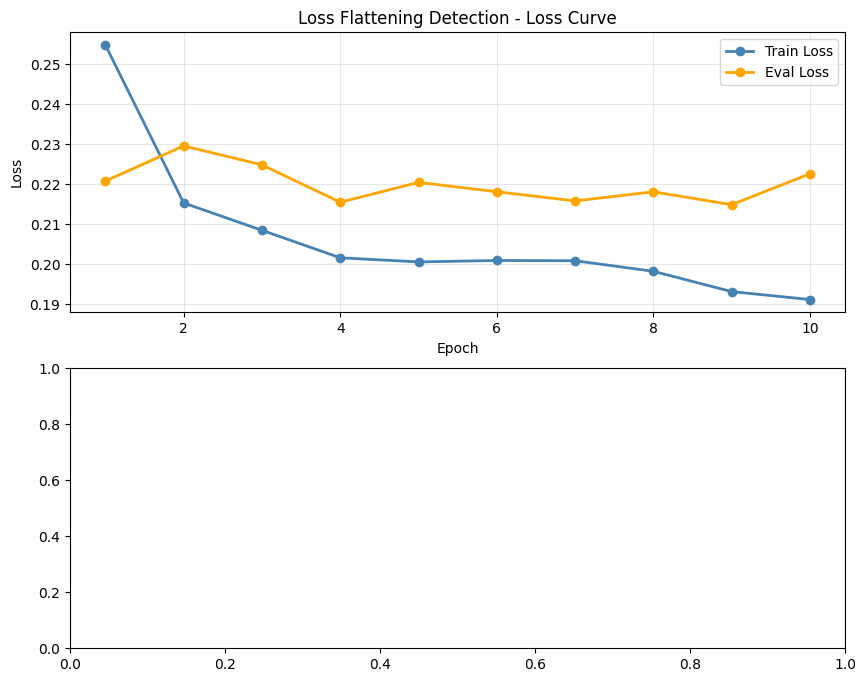


✓ Loss appears to flatten starting around epoch 6


In [5]:
plot_loss_flattening(train_losses, eval_losses, window_size=2)


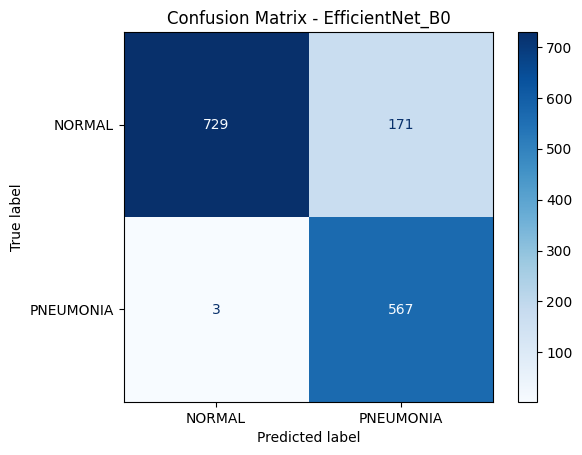

In [6]:

ConfusionMatrixDisplay.from_predictions(eval_labels, eval_preds.round(), display_labels=["NORMAL", "PNEUMONIA"], cmap="Blues")
plt.title("Confusion Matrix - EfficientNet_B0")
plt.show()